# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [ ]:
#  bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn



In [2]:
base = pd.read_csv('marketing_campaign.csv', delimiter=';')


# Exibir as primeiras linhas 
print("Primeiras linhas do dataset:")
print(base.head())



Primeiras linhas do dataset:
   Year_Birth   Education Marital_Status   Income  Kidhome  Recency  MntWines  \
0        1957  Graduation         Single  58138.0        0       58       635   
1        1954  Graduation         Single  46344.0        1       38        11   
2        1965  Graduation       Together  71613.0        0       26       426   
3        1984  Graduation       Together  26646.0        1       26        11   
4        1981         PhD        Married  58293.0        1       94       173   

   MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
0         88              546              172                88   
1          1                6                2                 1   
2         49              127              111                21   
3          4               20               10                 3   
4         43              118               46                27   

   MntGoldProds  NumStorePurchases  NumWebVisitsMonth  Complain  WebPurchas

In [3]:
# Informações gerais
print("\nResumo de tipos e valores nulos:")
print(base.info())

# Valores ausentes
print("\nValores ausentes por coluna:")
print(base.isnull().sum())

# Estatísticas descritivas (numeros)
print("\nEstatísticas descritivas:")
print(base.describe())




Resumo de tipos e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int

In [4]:
# Copiar dados 
base_pre = base.copy()

# valores nulos (coluna 'Income') 
base_pre['Income'] = base_pre['Income'].fillna(base_pre['Income'].median())

# Converter colunas 
cat_cols = ['Education', 'Marital_Status']
base_pre[cat_cols] = base_pre[cat_cols].astype('category')

# Criar coluna de idade com base em Year_Birth
base_pre['Age'] = 2025 - base_pre['Year_Birth']

# Criar nova variável: Gasto Total com produtos
gastos = ['MntWines', 'MntFruits', 'MntMeatProducts',
          'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
base_pre['Total_Spend'] = base_pre[gastos].sum(axis=1)

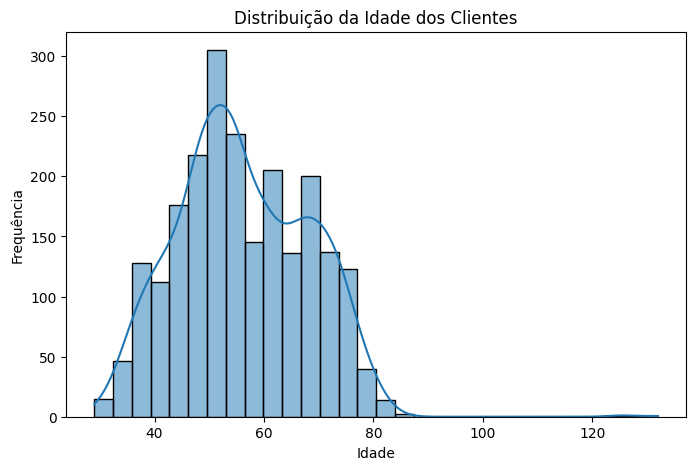

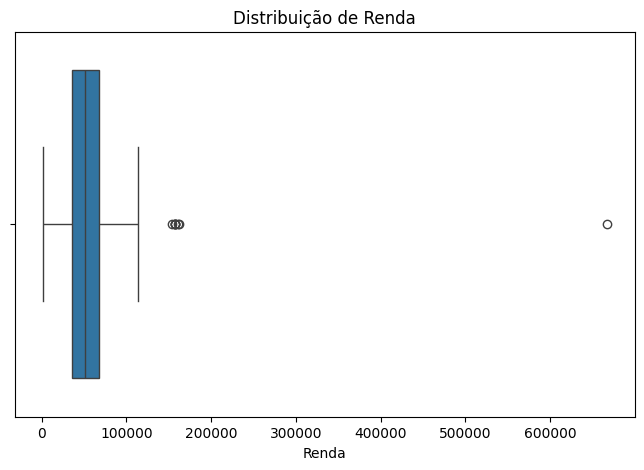

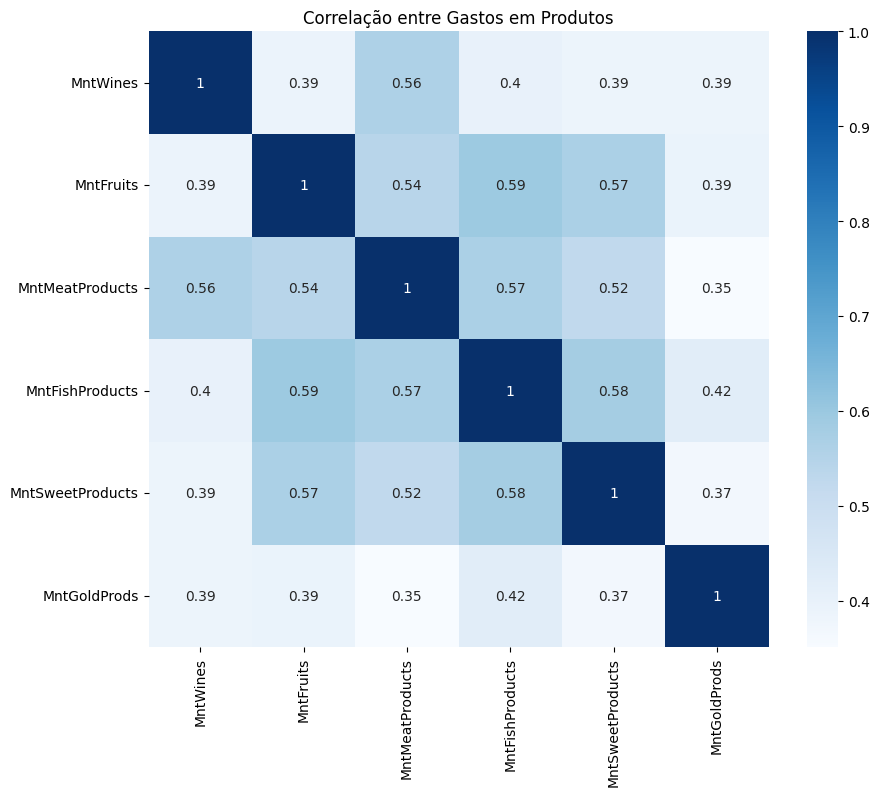

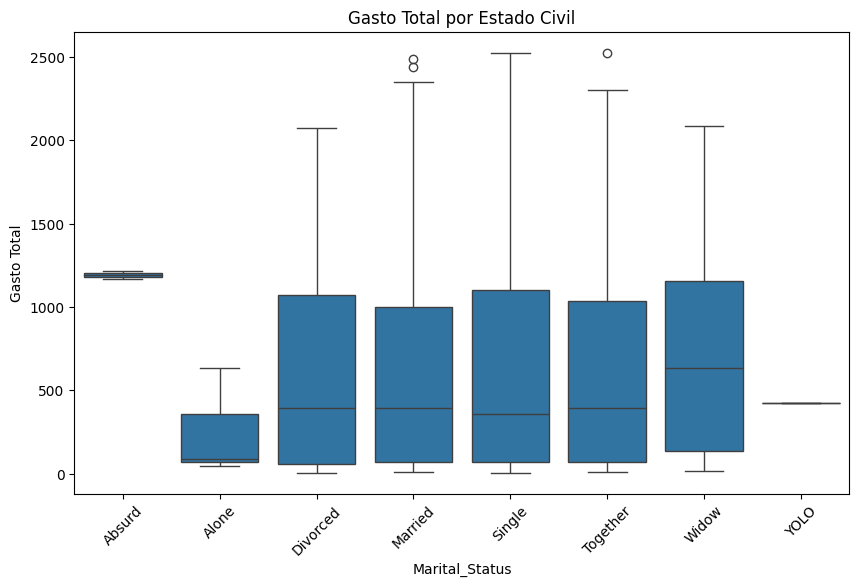

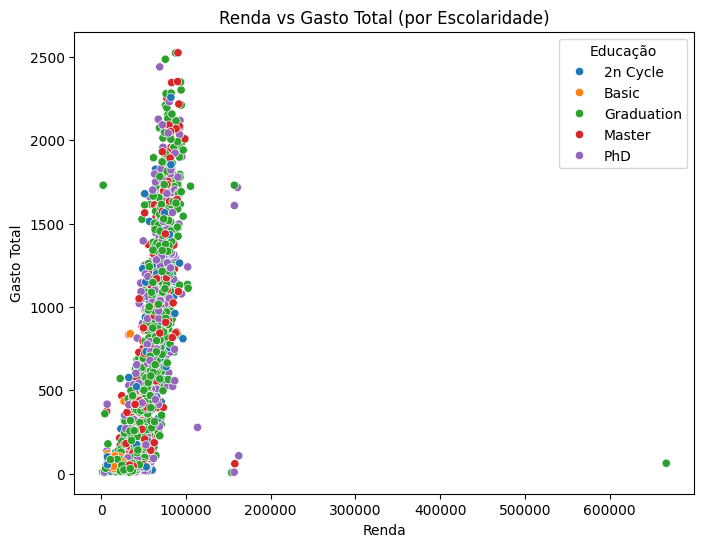

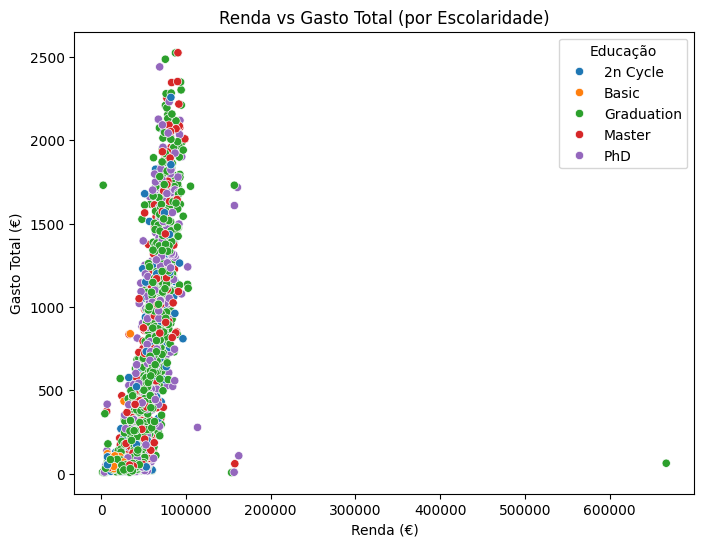

In [ ]:
# distribuição de idade
base_pre['Age'] = 2025 - base_pre['Year_Birth'] 
plt.figure(figsize=(8, 5))
sns.histplot(base_pre['Age'], kde=True, bins=30)
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# Análise de renda
plt.figure(figsize=(8, 5))
sns.boxplot(x=base_pre['Income'])
plt.title('Distribuição de Renda')
plt.xlabel('Renda')
plt.show()

# Correlação entre gastos
cols_gastos = ['MntWines', 'MntFruits', 'MntMeatProducts',
               'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
plt.figure(figsize=(10, 8))
sns.heatmap(base_pre[cols_gastos].corr(), annot=True, cmap='Blues')
plt.title('Correlação entre Gastos em Produtos')
plt.show()

# Gasto total em todos os produtos
base_pre['Total_Spend'] = base_pre[cols_gastos].sum(axis=1)

# Gasto total por estado civil
plt.figure(figsize=(10, 6))
sns.boxplot(data=base_pre, x='Marital_Status', y='Total_Spend')
plt.title('Gasto Total por Estado Civil')
plt.xticks(rotation=45)
plt.ylabel('Gasto Total')
plt.show()

# Renda vs Gasto Total
plt.figure(figsize=(8, 6))
sns.scatterplot(data=base_pre, x='Income', y='Total_Spend', hue='Education')
plt.title('Renda vs Gasto Total (por Escolaridade)')
plt.xlabel('Renda')
plt.ylabel('Gasto Total')
plt.legend(title='Educação')
plt.show()


# Relação entre Renda e Gasto Total, por Escolaridade
plt.figure(figsize=(8, 6))
sns.scatterplot(data=base_pre, x='Income', y='Total_Spend', hue='Education')
plt.title('Renda vs Gasto Total (por Escolaridade)')
plt.xlabel('Renda (€)')
plt.ylabel('Gasto Total (€)')
plt.legend(title='Educação')
plt.show()

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








In [ ]:
# Matriz de correlação apenas com variáveis numéricas
matriz_correlacao = base_nova.corr(numeric_only=True)

# Correlação de todas as variáveis com o Total Spend
print("Correlação com a variável alvo (Total_Spend):")
print(matriz_correlacao['Total_Spend'].sort_values(ascending=False))



Correlação com a variável alvo (Total_Spend):
Total_Spend          1.000000
MntWines             0.891839
MntMeatProducts      0.842965
NumStorePurchases    0.674669
Income               0.664775
MntFishProducts      0.642818
MntFruits            0.614229
MntSweetProducts     0.603016
WebPurchases         0.565239
MntGoldProds         0.524262
Age                  0.111306
Recency              0.020433
Complain            -0.037058
Year_Birth          -0.111306
NumWebVisitsMonth   -0.500218
Kidhome             -0.556669
Name: Total_Spend, dtype: float64


In [26]:
#Codificação de Variáveis Categóricas:

# Aplicar codificação one-hot nas variáveis categóricas
base_codificada = pd.get_dummies(base_nova, columns=['Education', 'Marital_Status'], drop_first=True)

# Verificar as novas colunas criadas
print("Colunas após a codificação das variáveis categóricas:")
print(base_codificada.columns)


Colunas após a codificação das variáveis categóricas:
Index(['Year_Birth', 'Income', 'Kidhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain',
       'WebPurchases', 'Age', 'Total_Spend', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')


In [23]:
#Separe a base em Y, X e Treino e teste:


from sklearn.model_selection import train_test_split

# Definir as variáveis independentes (X) e a variável alvo (y)
X = base_codificada.drop(columns=['Total_Spend', 'Year_Birth'])  # retiramos Year_Birth pois já temos a idade (Age)
y = base_codificada['Total_Spend']

# Dividir os dados entre treino (70%) e teste (30%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

# Mostrar o tamanho dos conjuntos
print(f"Tamanho dos dados de treino: {X_treino.shape}")
print(f"Tamanho dos dados de teste: {X_teste.shape}")



Tamanho dos dados de treino: (1568, 25)
Tamanho dos dados de teste: (672, 25)


In [27]:
# variáveis para classificação binária com padronização --- criadas por necessidade de seguir a etapa 3.

# variáveis preditoras (X) e alvo binário (y)
X = base_codificada.drop(columns=['Complain', 'Year_Birth']) # ja estamos usando "Age"
y = base_codificada['Complain']  # Variável alvo binária: 0 = não reclamou, 1 = reclamou

# dados em treino e teste (70% treino, 30% teste)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# dados numéricos com StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# formas das variáveis criadas
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_scaled: (1568, 25)
X_test_scaled: (672, 25)
y_train: (1568,)
y_test: (672,)


# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [37]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:

from imblearn.over_sampling import SMOTE

# SMOTE ao conjunto de treino já padronizado
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# nova distribuição da variável-alvo após balanceamento
import pandas as pd
print("Distribuição após SMOTE:")
print(pd.Series(y_train_resampled).value_counts(normalize=True))


Distribuição após SMOTE:
Complain
0    0.5
1    0.5
Name: proportion, dtype: float64


Acurácia - Random Forest (SMOTE): 0.9896


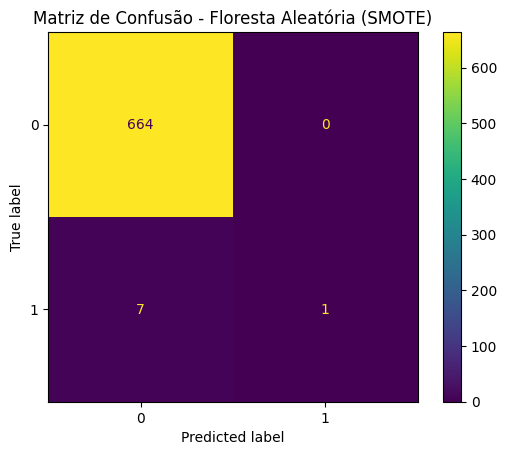

Relatório:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       664
           1       1.00      0.12      0.22         8

    accuracy                           0.99       672
   macro avg       0.99      0.56      0.61       672
weighted avg       0.99      0.99      0.99       672



In [42]:


## MODELO 1 - RANDOM FOREST

# Importa a biblioteca do modelo Random Forest e as métricas para avaliação
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cria o modelo de Floresta Aleatória com 100 árvores
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Treina o modelo usando os dados de treino balanceados com SMOTE
modelo_rf.fit(X_train_resampled, y_train_resampled)

# Realiza a previsão nos dados de teste (que não foram balanceados)
y_pred_rf = modelo_rf.predict(X_test_scaled)

# Imprime a acurácia do modelo
print(f"Acurácia - Random Forest (SMOTE): {accuracy_score(y_test, y_pred_rf):.4f}")

# Exibe a matriz de confusão para avaliar como o modelo classificou cada classe
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_test_scaled, y_test)
plt.title("Matriz de Confusão - Floresta Aleatória (SMOTE)")
plt.show()

# Mostra um relatório completo com precisão, recall e F1-score para cada classe
print("Relatório:")
print(classification_report(y_test, y_pred_rf, zero_division=0))





Acurácia - Regressão Logística (SMOTE): 0.7173


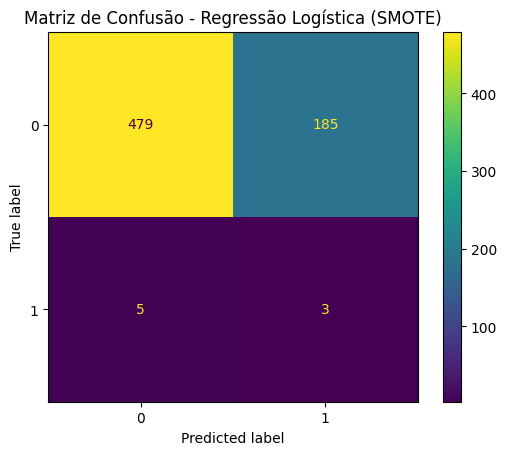

Relatório:
              precision    recall  f1-score   support

           0       0.99      0.72      0.83       664
           1       0.02      0.38      0.03         8

    accuracy                           0.72       672
   macro avg       0.50      0.55      0.43       672
weighted avg       0.98      0.72      0.82       672



In [43]:
# MODELO 2 - REGRESSÃO LOGISTICA

from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_train_resampled, y_train_resampled)

y_pred_log = modelo_log.predict(X_test_scaled)
print(f"Acurácia - Regressão Logística (SMOTE): {accuracy_score(y_test, y_pred_log):.4f}")

ConfusionMatrixDisplay.from_estimator(modelo_log, X_test_scaled, y_test)
plt.title("Matriz de Confusão - Regressão Logística (SMOTE)")
plt.show()

print("Relatório:")
print(classification_report(y_test, y_pred_log, zero_division=0))




Acurácia - SVM Linear (SMOTE): 0.6726


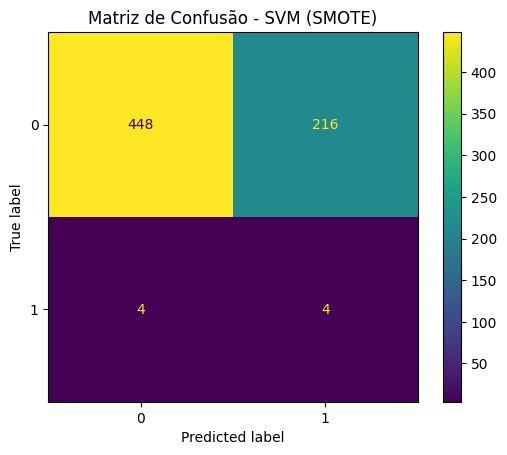

Relatório:
              precision    recall  f1-score   support

           0       0.99      0.67      0.80       664
           1       0.02      0.50      0.04         8

    accuracy                           0.67       672
   macro avg       0.50      0.59      0.42       672
weighted avg       0.98      0.67      0.79       672



In [44]:
## MODELO 3 - SVM com Kernel Linear

from sklearn.svm import SVC

modelo_svm = SVC(kernel='linear', probability=True, random_state=42)
modelo_svm.fit(X_train_resampled, y_train_resampled)

y_pred_svm = modelo_svm.predict(X_test_scaled)
print(f"Acurácia - SVM Linear (SMOTE): {accuracy_score(y_test, y_pred_svm):.4f}")

ConfusionMatrixDisplay.from_estimator(modelo_svm, X_test_scaled, y_test)
plt.title("Matriz de Confusão - SVM (SMOTE)")
plt.show()

print("Relatório:")
print(classification_report(y_test, y_pred_svm, zero_division=0))


Acurácia - KNN (SMOTE): 0.9345


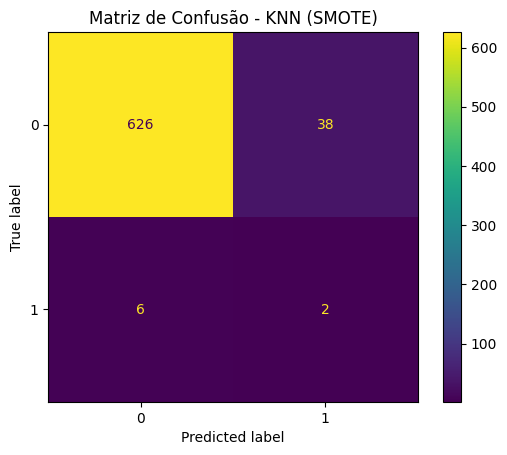

Relatório:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       664
           1       0.05      0.25      0.08         8

    accuracy                           0.93       672
   macro avg       0.52      0.60      0.52       672
weighted avg       0.98      0.93      0.96       672



In [45]:

## Modelo 4 – KNN (k=5)

from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_resampled, y_train_resampled)

y_pred_knn = modelo_knn.predict(X_test_scaled)
print(f"Acurácia - KNN (SMOTE): {accuracy_score(y_test, y_pred_knn):.4f}")

ConfusionMatrixDisplay.from_estimator(modelo_knn, X_test_scaled, y_test)
plt.title("Matriz de Confusão - KNN (SMOTE)")
plt.show()

print("Relatório:")
print(classification_report(y_test, y_pred_knn, zero_division=0))




# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

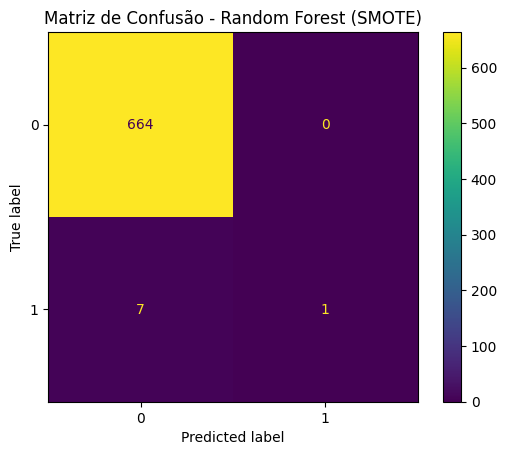


📊 Relatório - Random Forest (SMOTE):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       664
           1       1.00      0.12      0.22         8

    accuracy                           0.99       672
   macro avg       0.99      0.56      0.61       672
weighted avg       0.99      0.99      0.99       672



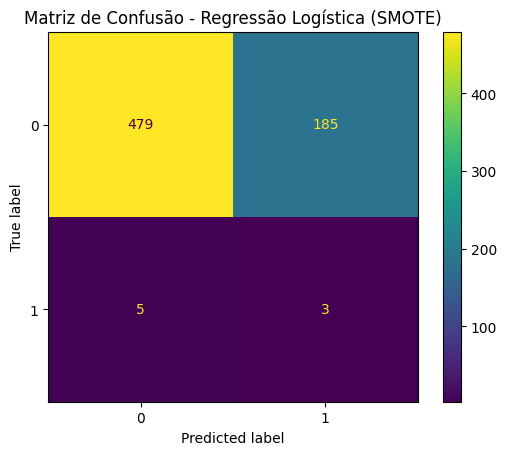


📊 Relatório - Regressão Logística (SMOTE):
              precision    recall  f1-score   support

           0       0.99      0.72      0.83       664
           1       0.02      0.38      0.03         8

    accuracy                           0.72       672
   macro avg       0.50      0.55      0.43       672
weighted avg       0.98      0.72      0.82       672


✅ Comparativo de desempenho:


,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Random Forest (SMOTE),0.989583,1.000000,0.125,0.222222
1,Regressão Logística (SMOTE),0.717262,0.015957,0.375,0.030612


In [ ]:

## Avaliando Random Forest e Regressão Logística

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Lista com modelos e nomes
modelos = {
    'Random Forest (SMOTE)': modelo_rf,
    'Regressão Logística (SMOTE)': modelo_log
}

# Dicionário para guardar as métricas
resultados = []

# Avaliar cada modelo
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Armazena os resultados
    resultados.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # Exibe a matriz de confusão
    ConfusionMatrixDisplay.from_estimator(modelo, X_test_scaled, y_test)
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()

    # Relatório completo
    print(f"\n📊 Relatório - {nome}:")
    print(classification_report(y_test, y_pred, zero_division=0))

# Mostrar tabela com comparativo
df_resultados = pd.DataFrame(resultados)
print("\n✅ Comparativo de desempenho:")
display(df_resultados.sort_values(by='F1-Score', ascending=False))
